# R05 — Fire Power Prediction Accuracy

**Goal:** Compare our ML model's fire power predictions vs actual opponent behavior.

Our GBM model predicts how much bullet power the opponent will use (`PREDICTED_FIRE_POWER`).
We compare predictions at fire-detection ticks against actual fire power from waves data.

In [1]:
import sys; sys.path.insert(0, '..')
from retrospective._retro_helpers import load_local_ticks, load_local_waves, add_opponent_names
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

# Load ticks (subsample for memory) and waves
ticks = add_opponent_names(load_local_ticks(row_frac=0.3))
waves = add_opponent_names(load_local_waves())
print(f'Ticks: {len(ticks):,} rows, Waves: {len(waves):,} rows')
print(f'Tick columns containing "predict": {[c for c in ticks.columns if "predict" in c.lower()]}')
print(f'Wave columns containing "power" or "bullet": {[c for c in waves.columns if "power" in c.lower() or "bullet" in c.lower()]}')

Indexed 50 ticks.csv files across 6 distinct robots from 1 root(s).
Selected 6 robots × ~100 battles = 50 (battle, robot) pairs to load.


Loaded 50 ticks.csv files → 261,342 rows × 87 cols, 6 robots (~110.7 MB)
Indexed 50 ticks.csv files across 6 distinct robots from 1 root(s).
Selected 6 robots × ~100 battles = 50 (battle, robot) pairs to load.


Loaded 50 waves.csv files → 32,516 rows × 13 cols, 6 robots (~5.5 MB)
Ticks: 130,671 rows, Waves: 19,331 rows
Tick columns containing "predict": []
Wave columns containing "power" or "bullet": ['wave_bullet_power', 'wave_bullet_speed']


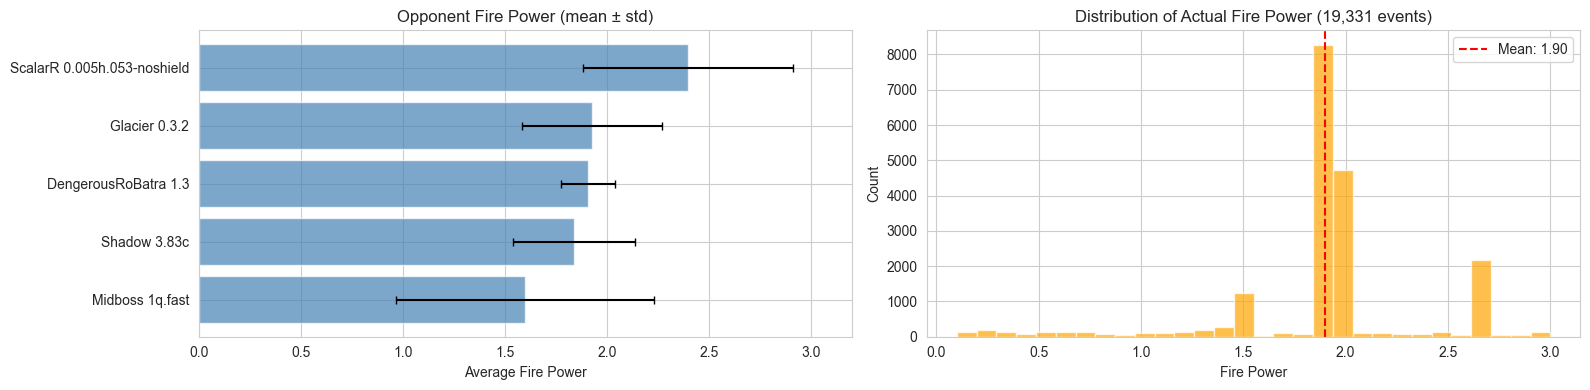

              opponent_name  mean_power  std_power  fire_events
            Midboss 1q.fast       1.596      0.633         4266
               Shadow 3.83c       1.838      0.297         4039
       DengerousRoBatra 1.3       1.904      0.132         4388
              Glacier 0.3.2       1.926      0.342         3830
ScalarR 0.005h.053-noshield       2.398      0.516         2808


In [2]:
# Actual fire power distribution from waves
actual_col = next((c for c in waves.columns if 'bullet_power' in c.lower()), None)
if actual_col and len(waves) > 0:
    opp_fp = waves.groupby('opponent_name')[actual_col].agg(['mean', 'std', 'count']).reset_index()
    opp_fp.columns = ['opponent_name', 'mean_power', 'std_power', 'fire_events']
    opp_fp = opp_fp.sort_values('mean_power')
    
    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(opp_fp)*0.5)))
    
    ax = axes[0]
    ax.barh(opp_fp['opponent_name'], opp_fp['mean_power'], xerr=opp_fp['std_power'], 
            color='steelblue', alpha=0.7, capsize=3)
    ax.set_xlabel('Average Fire Power')
    ax.set_title('Opponent Fire Power (mean ± std)')
    ax.set_xlim(0, 3.2)
    
    ax = axes[1]
    ax.hist(waves[actual_col].dropna(), bins=30, color='orange', alpha=0.7, edgecolor='white')
    ax.set_xlabel('Fire Power')
    ax.set_ylabel('Count')
    ax.set_title(f'Distribution of Actual Fire Power ({len(waves):,} events)')
    ax.axvline(x=waves[actual_col].mean(), color='red', linestyle='--', 
               label=f'Mean: {waves[actual_col].mean():.2f}')
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    print(opp_fp.to_string(index=False, float_format=lambda x: f'{x:.3f}'))
else:
    print(f'Fire power column not found. Wave columns: {list(waves.columns)}')

In [3]:
# Check if prediction column exists in ticks and compare
pred_col = next((c for c in ticks.columns if 'predicted_fire_power' in c.lower()), None)
if pred_col and len(ticks) > 0:
    # Get predicted fire power at fire-detection ticks
    fire_ticks = ticks[ticks.get('opponent_fired', 0) == 1].copy()
    if len(fire_ticks) > 0:
        print(f'Fire ticks with predictions: {len(fire_ticks):,}')
        print(f'Mean predicted fire power: {fire_ticks[pred_col].mean():.3f}')
        if actual_col:
            print(f'Mean actual fire power: {waves[actual_col].mean():.3f}')
    else:
        print('No fire-detection ticks found in sampled data (try higher row_frac).')
else:
    print(f'Prediction column not found in ticks.')
    print('This is expected if ML model predictions are not yet wired into tick output.')
    print('The fire power data above shows actual opponent behavior for future comparison.')

Prediction column not found in ticks.
This is expected if ML model predictions are not yet wired into tick output.
The fire power data above shows actual opponent behavior for future comparison.
